In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [128]:
df1 = pd.read_csv('sesi-1.csv')
df2 = pd.read_csv('sesi-2.csv')

In [129]:
def konversi_waktu_ke_menit(waktu_str):
    if pd.isna(waktu_str):
        return 0
    jam, menit, detik = map(int, str(waktu_str).split(':'))
    return (jam * 60) + menit + (detik / 60.0)

df1['total_waktu_menit'] = df1['total_waktu'].apply(konversi_waktu_ke_menit)
df2['total_waktu_menit'] = df2['total_waktu'].apply(konversi_waktu_ke_menit)

In [130]:
df1['nama_clean'] = df1['nama'].str.strip().str.lower()
df2['nama_clean'] = df2['nama'].str.strip().str.lower()

In [131]:
df1_clean = df1.sort_values(by='skor_akhir', ascending=False).drop_duplicates(subset=['nama_clean'], keep='first')
df2_clean = df2.sort_values(by='skor_akhir', ascending=False).drop_duplicates(subset=['nama_clean'], keep='first')

In [132]:
df_merged = pd.merge(
    df1_clean, df2_clean, 
    on='nama_clean', 
    suffixes=('_sesi1', '_sesi2'), 
    how='inner'
)

In [133]:
print(f"Total data siswa terekstrak dari sesi 1: {len(df1_clean)}")
print(f"Total data siswa terekstrak dari sesi 2: {len(df2_clean)}")
print(f"Total data siswa yang ikut keduanya    : {len(df_merged)}")

Total data siswa terekstrak dari sesi 1: 61
Total data siswa terekstrak dari sesi 2: 55
Total data siswa yang ikut keduanya    : 53


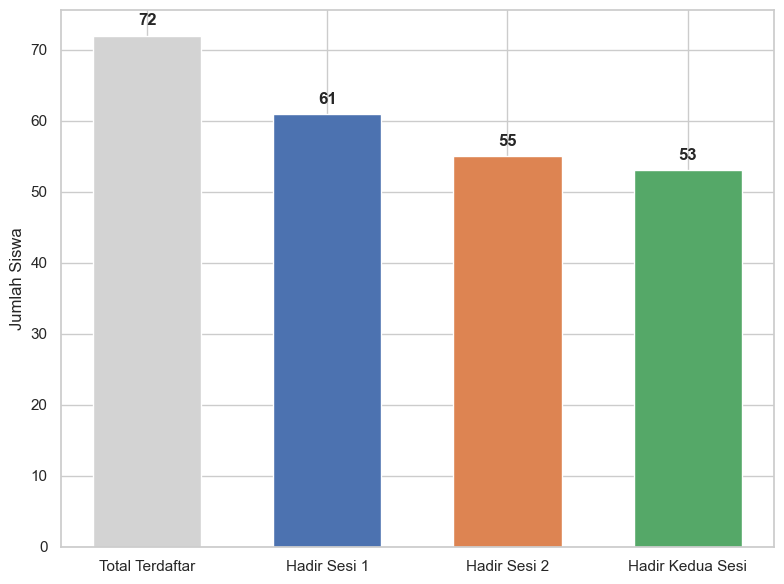

In [134]:
plt.figure(figsize=(8, 6))

kategori = ['Total Terdaftar', 'Hadir Sesi 1', 'Hadir Sesi 2', 'Hadir Kedua Sesi']
jumlah = [72, len(df1_clean), len(df2_clean), len(df_merged)]
warna = ['#d3d3d3', '#4c72b0', '#dd8452', '#55a868']

bars = plt.bar(kategori, jumlah, color=warna, width=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylabel('Jumlah Siswa')
# plt.title('Diagram Proses Pra-pemrosesan Data', fontsize=14, fontweight='bold', pad=20)
# plt.figtext(0.5, -0.05, 'Gambar 4.9. Proses pra-pemrosesan data: dari 72 siswa terdaftar\nmenjadi 56 data valid untuk analisis perbandingan.', wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic')

plt.tight_layout()
plt.show()

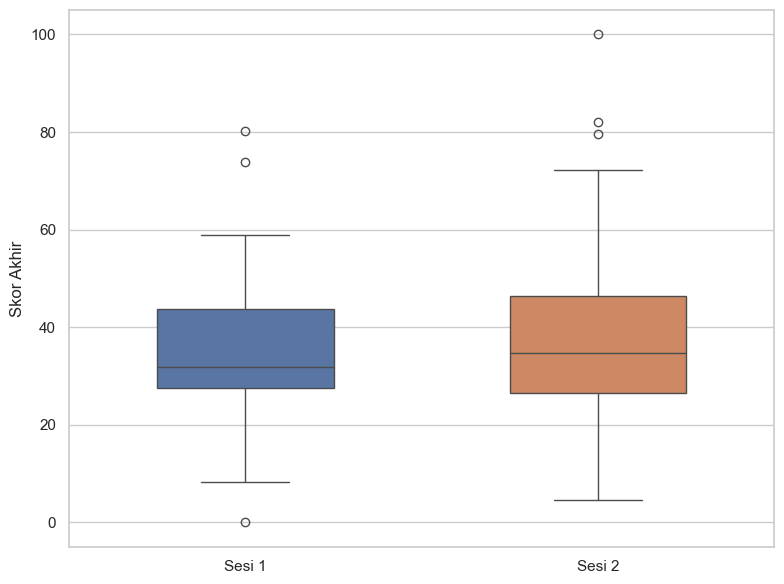

In [135]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df_merged[['skor_akhir_sesi1', 'skor_akhir_sesi2']], palette=['#4c72b0', '#dd8452'], width=0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Sesi 1', 'Sesi 2'])

plt.ylabel('Skor Akhir')
# plt.title('Perbandingan Distribusi Skor Akhir', fontsize=14, fontweight='bold')
# plt.figtext(0.5, -0.05, 'Gambar 4.10. Distribusi skor akhir siswa pada Sesi 1 (CBT Konvensional)\ndan Sesi 2 (CAT Rule-Based) (n = 56).', wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic')
plt.tight_layout()
plt.show()

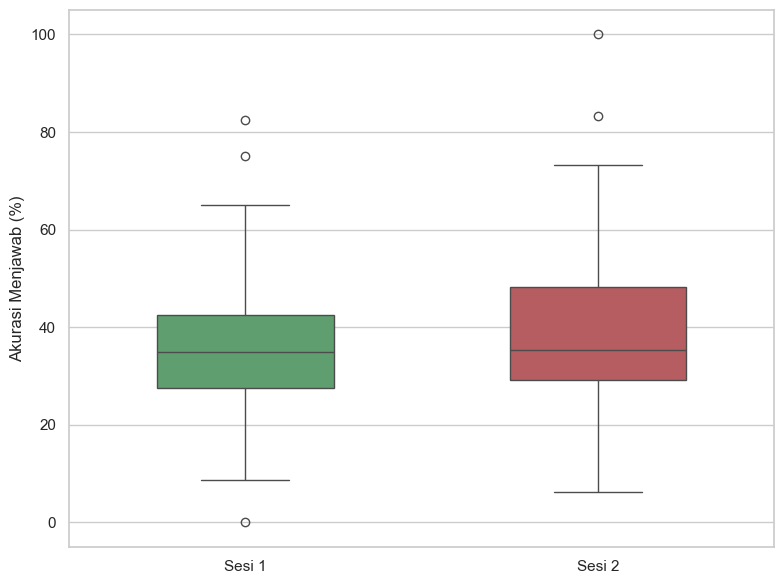

In [136]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df_merged[['akurasi_menjawab_sesi1', 'akurasi_menjawab_sesi2']], palette=['#55a868', '#c44e52'], width=0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Sesi 1', 'Sesi 2'])

plt.ylabel('Akurasi Menjawab (%)')
# plt.title('Perbandingan Distribusi Akurasi Menjawab', fontsize=14, fontweight='bold')
# plt.figtext(0.5, -0.05, 'Gambar 4.11. Distribusi akurasi menjawab siswa pada Sesi 1 (CBT)\ndan Sesi 2 (CAT Rule-Based) (n = 56).', wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic')
plt.tight_layout()
plt.show()

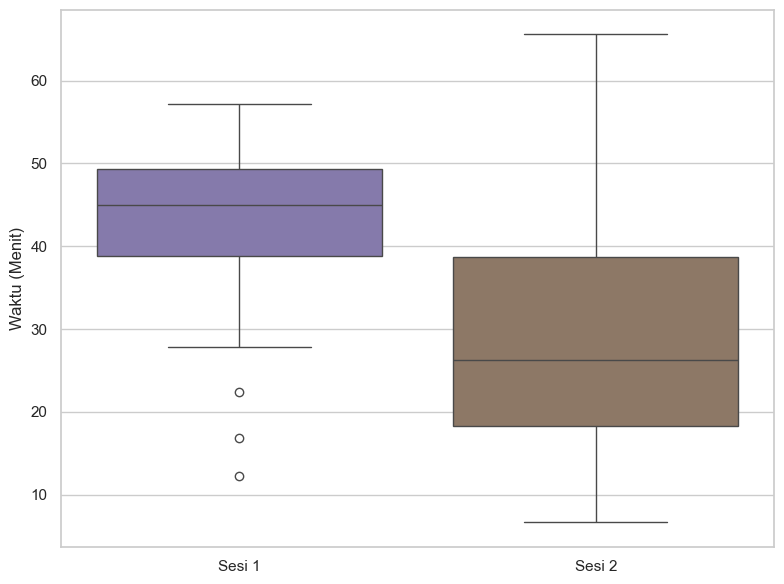

In [137]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df_merged[['total_waktu_menit_sesi1', 'total_waktu_menit_sesi2']], palette=['#8172b3', '#937860'])
# boxplot untuk waktu pengerjaan
ax.set_xticks([0, 1])
ax.set_xticklabels(['Sesi 1', 'Sesi 2'])

plt.ylabel('Waktu (Menit)')
# plt.title('Perbandingan Distribusi Waktu Pengerjaan', fontsize=14, fontweight='bold')
# plt.figtext(0.5, -0.05, 'Gambar 4.12. Distribusi waktu pengerjaan siswa pada Sesi 1 (CBT)\ndan Sesi 2 (CAT Rule-Based) (n = 56).', wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic')
plt.tight_layout()
plt.show()

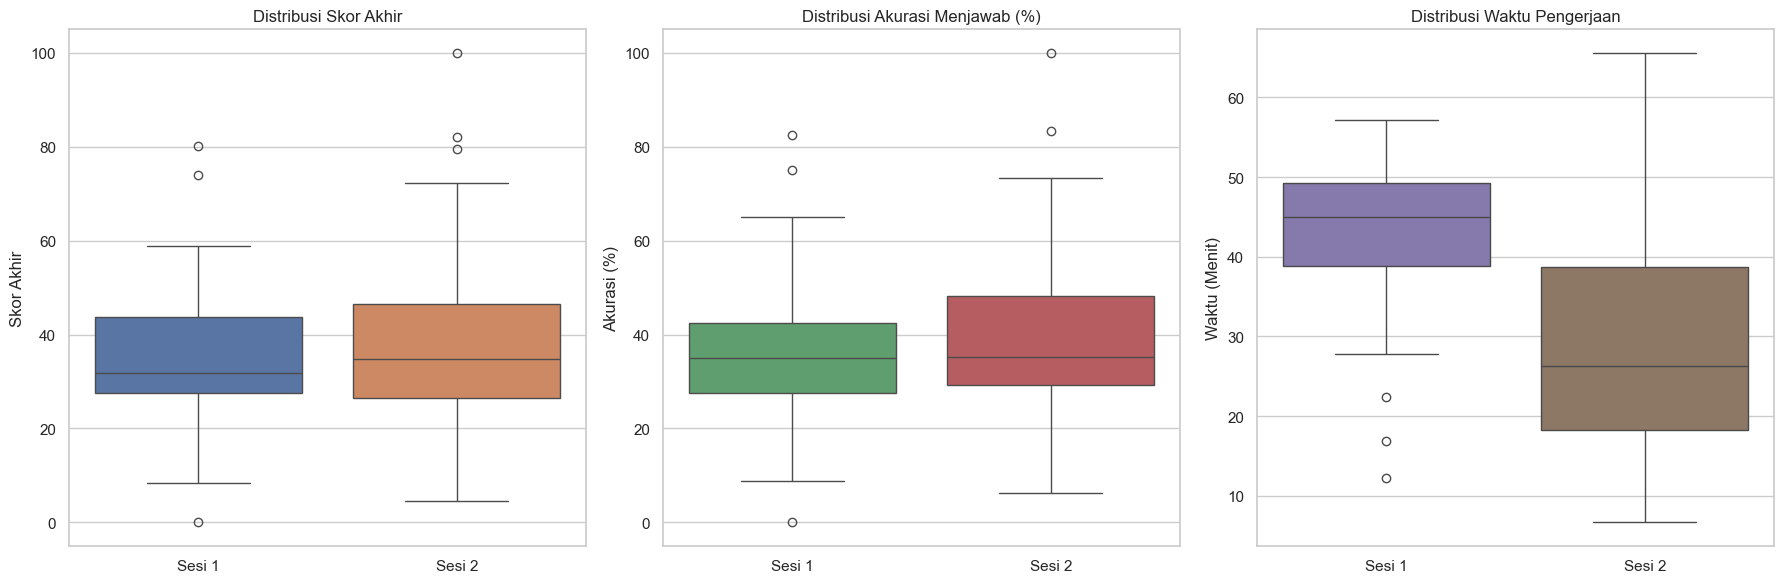

In [138]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# fig.suptitle('Perbandingan Keseluruhan Performa Asesmen (n = 56)', fontsize=16, fontweight='bold', y=1.05)

sns.boxplot(data=df_merged[['skor_akhir_sesi1', 'skor_akhir_sesi2']], ax=axes[0], palette=['#4c72b0', '#dd8452'])
axes[0].set_title('Distribusi Skor Akhir')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sesi 1', 'Sesi 2'])
axes[0].set_ylabel('Skor Akhir')

sns.boxplot(data=df_merged[['akurasi_menjawab_sesi1', 'akurasi_menjawab_sesi2']], ax=axes[1], palette=['#55a868', '#c44e52'])
axes[1].set_title('Distribusi Akurasi Menjawab (%)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Sesi 1', 'Sesi 2'])
axes[1].set_ylabel('Akurasi (%)')

sns.boxplot(data=df_merged[['total_waktu_menit_sesi1', 'total_waktu_menit_sesi2']], ax=axes[2], palette=['#8172b3', '#937860'])
axes[2].set_title('Distribusi Waktu Pengerjaan')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Sesi 1', 'Sesi 2'])
axes[2].set_ylabel('Waktu (Menit)')

# plt.figtext(0.5, -0.05, 'Gambar 4.12. Perbandingan distribusi (a) Skor Akhir, (b) Akurasi Menjawab, dan (c) Waktu Pengerjaan\nantara Sesi 1 (CBT) dan Sesi 2 (CAT Rule-Based) pada 56 siswa valid.', wrap=True, horizontalalignment='center', fontsize=12, fontstyle='italic')
plt.tight_layout()
plt.show()

In [139]:
print("="*60)
print(f"ANALISIS STATISTIK DESKRIPTIF (N = {len(df_merged)})")
print("="*60)

def cetak_statistik(nama_variabel, col1, col2):
    print(f"--- {nama_variabel.upper()} ---")
    print(f"{'Metrik':<15} | {'Sesi 1':<15} | {'Sesi 2':<15}")
    print("-" * 50)
    print(f"{'Mean (Rata2)':<15} | {df_merged[col1].mean():<15.2f} | {df_merged[col2].mean():<15.2f}")
    print(f"{'Median (Tengah)':<15} | {df_merged[col1].median():<15.2f} | {df_merged[col2].median():<15.2f}")
    
    mod1 = df_merged[col1].mode().iloc[0] if not df_merged[col1].mode().empty else np.nan
    mod2 = df_merged[col2].mode().iloc[0] if not df_merged[col2].mode().empty else np.nan
    print(f"{'Modus':<15} | {mod1:<15.2f} | {mod2:<15.2f}")
    
    print(f"{'Std. Deviasi':<15} | {df_merged[col1].std():<15.2f} | {df_merged[col2].std():<15.2f}")
    print(f"{'Nilai Tertinggi':<15} | {df_merged[col1].max():<15.2f} | {df_merged[col2].max():<15.2f}")
    print(f"{'Nilai Terendah':<15} | {df_merged[col1].min():<15.2f} | {df_merged[col2].min():<15.2f}")
    print("\n")

cetak_statistik("Skor Akhir", 'skor_akhir_sesi1', 'skor_akhir_sesi2')
cetak_statistik("Akurasi Menjawab (%)", 'akurasi_menjawab_sesi1', 'akurasi_menjawab_sesi2')
cetak_statistik("Total Waktu (Menit)", 'total_waktu_menit_sesi1', 'total_waktu_menit_sesi2')

ANALISIS STATISTIK DESKRIPTIF (N = 53)
--- SKOR AKHIR ---
Metrik          | Sesi 1          | Sesi 2         
--------------------------------------------------
Mean (Rata2)    | 34.67           | 37.83          
Median (Tengah) | 31.86           | 34.78          
Modus           | 0.00            | 26.47          
Std. Deviasi    | 15.36           | 19.36          
Nilai Tertinggi | 80.23           | 100.00         
Nilai Terendah  | 0.00            | 4.55           


--- AKURASI MENJAWAB (%) ---
Metrik          | Sesi 1          | Sesi 2         
--------------------------------------------------
Mean (Rata2)    | 35.17           | 39.66          
Median (Tengah) | 35.00           | 35.29          
Modus           | 30.00           | 6.67           
Std. Deviasi    | 15.23           | 18.97          
Nilai Tertinggi | 82.50           | 100.00         
Nilai Terendah  | 0.00            | 6.25           


--- TOTAL WAKTU (MENIT) ---
Metrik          | Sesi 1          | Sesi 2         

In [156]:
# ========================================================
# UJI PRASYARAT: UJI NORMALITAS (SHAPIRO-WILK)
# ========================================================
print("="*60)
print("UJI NORMALITAS SHAPIRO-WILK (N = 53)")
print("Syarat: Jika p-value > 0.05, maka data berdistribusi Normal")
print("="*60)

# Menghitung selisih (delta) antara Sesi 2 dan Sesi 1
diff_skor = df_merged['skor_akhir_sesi2'] - df_merged['skor_akhir_sesi1']
diff_akurasi = df_merged['akurasi_menjawab_sesi2'] - df_merged['akurasi_menjawab_sesi1']
diff_waktu = df_merged['total_waktu_menit_sesi2'] - df_merged['total_waktu_menit_sesi1']

# Fungsi bantuan untuk print hasil
def cek_normalitas(nama_variabel, data_diff):
    stat, p = stats.shapiro(data_diff)
    distribusi = "Normal" if p > 0.05 else "TIDAK Normal"
    uji_lanjutan = "Paired T-Test" if p > 0.05 else "Wilcoxon Signed-Rank Test"
    
    print(f"Variabel       : Selisih {nama_variabel}")
    print(f"P-Value        : {p:.5f}")
    print(f"Kesimpulan     : Data berdistribusi {distribusi}")
    print(f"Rekomendasi Uji: Gunakan {uji_lanjutan}\n")

cek_normalitas("Skor Akhir", diff_skor)
cek_normalitas("Akurasi Menjawab", diff_akurasi)
cek_normalitas("Waktu Pengerjaan", diff_waktu)

UJI NORMALITAS SHAPIRO-WILK (N = 53)
Syarat: Jika p-value > 0.05, maka data berdistribusi Normal
Variabel       : Selisih Skor Akhir
P-Value        : 0.00014
Kesimpulan     : Data berdistribusi TIDAK Normal
Rekomendasi Uji: Gunakan Wilcoxon Signed-Rank Test

Variabel       : Selisih Akurasi Menjawab
P-Value        : 0.00004
Kesimpulan     : Data berdistribusi TIDAK Normal
Rekomendasi Uji: Gunakan Wilcoxon Signed-Rank Test

Variabel       : Selisih Waktu Pengerjaan
P-Value        : 0.08182
Kesimpulan     : Data berdistribusi Normal
Rekomendasi Uji: Gunakan Paired T-Test



In [140]:
print("="*60)
print("HASIL UJI HIPOTESIS (INFERENSIAL)")
print("="*60)

# UJI WILCOXON SIGNED-RANK UNTUK SKOR AKHIR DAN AKURASI 
# Digunakan karena distribusi skor biasanya tidak berdistribusi normal dengan sempurna
stat_skor, p_skor = stats.wilcoxon(df_merged['skor_akhir_sesi1'], df_merged['skor_akhir_sesi2'])
stat_akurasi, p_akurasi = stats.wilcoxon(df_merged['akurasi_menjawab_sesi1'], df_merged['akurasi_menjawab_sesi2'])

print("Uji Wilcoxon Signed-Rank (Skor Akhir):")
print(f"   - Statistik Uji : {stat_skor:.2f}")
print(f"   - P-Value       : {p_skor:.5f}")
if p_skor < 0.05:
    print("   - Kesimpulan    : Terdapat perbedaan yang SIGNIFIKAN pada Skor Akhir antara CBT dan CAT.\n")
else:
    print("   - Kesimpulan    : TIDAK terdapat perbedaan signifikan pada Skor Akhir.\n")

print("Uji Wilcoxon Signed-Rank (Akurasi Menjawab):")
print(f"   - Statistik Uji : {stat_akurasi:.2f}")
print(f"   - P-Value       : {p_akurasi:.5f}")
if p_akurasi < 0.05:
    print("   - Kesimpulan    : Terdapat perbedaan yang SIGNIFIKAN pada Akurasi antara CBT dan CAT.\n")
else:
    print("   - Kesimpulan    : TIDAK terdapat perbedaan signifikan pada Akurasi.\n")

# UJI PAIRED T-TEST UNTUK WAKTU UJIAN
# Digunakan karena waktu ujian biasanya data kontinu numerik berskala rasio
stat_waktu, p_waktu = stats.ttest_rel(df_merged['total_waktu_menit_sesi1'], df_merged['total_waktu_menit_sesi2'])

print("Uji Paired T-Test (Waktu Pengerjaan Ujian):")
print(f"   - T-Statistic   : {stat_waktu:.2f}")
print(f"   - P-Value       : {p_waktu:.5f}")
if p_waktu < 0.05:
    print("   - Kesimpulan    : Terdapat perbedaan yang SIGNIFIKAN pada Waktu Pengerjaan antara CBT dan CAT.\n")
else:
    print("   - Kesimpulan    : TIDAK terdapat perbedaan signifikan pada Waktu Pengerjaan.\n")

HASIL UJI HIPOTESIS (INFERENSIAL)
Uji Wilcoxon Signed-Rank (Skor Akhir):
   - Statistik Uji : 601.00
   - P-Value       : 0.31075
   - Kesimpulan    : TIDAK terdapat perbedaan signifikan pada Skor Akhir.

Uji Wilcoxon Signed-Rank (Akurasi Menjawab):
   - Statistik Uji : 552.50
   - P-Value       : 0.14902
   - Kesimpulan    : TIDAK terdapat perbedaan signifikan pada Akurasi.

Uji Paired T-Test (Waktu Pengerjaan Ujian):
   - T-Statistic   : 6.03
   - P-Value       : 0.00000
   - Kesimpulan    : Terdapat perbedaan yang SIGNIFIKAN pada Waktu Pengerjaan antara CBT dan CAT.



In [141]:
df_kuesioner = pd.read_csv('kuesioner.csv')

In [142]:
df_kuesioner = df_kuesioner.drop_duplicates(subset=['Nama Lengkap'], keep='last')

In [143]:
df_kuesioner['nama_kuesioner_clean'] = df_kuesioner['Nama Lengkap'].astype(str).str.strip().str.lower()

In [144]:
valid_names = df_merged['nama_clean'].tolist()

In [145]:
def cocokkan_nama(nama_k):

    if nama_k in valid_names:
        return nama_k

    if 'aulia' in nama_k or 'alya sarafataya' in nama_k: return 'aulia'
    if 'faisal afgan' in nama_k: return 'muhammad faisal afgan'
    if 'ridwan manzini' in nama_k: return 'muhammad ridwan manzini'
    if 'riskuna' in nama_k: return 'kasifa hiskuna'
    if 'syifa nazril' in nama_k: return 'syfaa nazril' # Diubah agar tidak menabrak Nisa Assyifa
    if 'sheyllomita' in nama_k: return 'deswita kanaya sheylomita'
    if 'salsabila' in nama_k and 'keyla' in nama_k: return 'keyla salsabilla'
    if 'aurelia' in nama_k: return 'callysta aryago aryaago'

    if 'faid mubaraq' in nama_k: return 'muhammad faid mubaraq'
    if 'zikri al mujaddidi' in nama_k: return 'muhammad zikri al mujaddidi'

    for v_name in valid_names:
        if v_name in nama_k or nama_k in v_name:
            return v_name
            
    return None

In [146]:
df_kuesioner['nama_matched'] = df_kuesioner['nama_kuesioner_clean'].apply(cocokkan_nama)

In [147]:
df_kuesioner_valid = df_kuesioner[df_kuesioner['nama_matched'].notna()]

In [148]:
df_final = pd.merge(
    df_merged, 
    df_kuesioner_valid, 
    left_on='nama_clean', 
    right_on='nama_matched', 
    how='inner'
)

In [149]:
print("="*60)
print(f"Total data siswa yang ikut keduanya    : {len(df_merged)}")
print(f"Total kuesioner terekstrak dari N={len(df_merged)}   : {len(df_final)}")
print("="*60)

print("\nDAFTAR SISWA YANG MENGIKUTI KEDUA SESI (N = 53):")
print("-" * 50)
daftar_siswa = df_merged['nama_sesi1'].sort_values().tolist()
for i, nama in enumerate(daftar_siswa, 1):
    print(f"{i:02d}. {nama}")
print("-" * 50)

Total data siswa yang ikut keduanya    : 53
Total kuesioner terekstrak dari N=53   : 53

DAFTAR SISWA YANG MENGIKUTI KEDUA SESI (N = 53):
--------------------------------------------------
01. Ahmad Razan Alamsyah
02. Aisyah Annuri
03. Al Falah Akbar Taulani
04. Amalina Zahratin
05. As Sohih Imaduddin
06. Asla Rasyiqah Jamal
07. Aulia
08. Baiq Erji Sahaya
09. Callysta Aryago Aryaago
10. Deswita Kanaya Sheylomita
11. Driandra Gita Khoirunisa
12. Farid Asyraf Pratama
13. Fatih Arrayan
14. Faza Wirangsane
15. Fina Maisara
16. Haula Yuanida Zahra
17. Ila Ngastonima Riska Rahmadani
18. Irfan Abdullah Ghaffari
19. Izzuddin Majdi Islam
20. Jenna Putri Defa
21. Kasifa Hiskuna
22. Keyla Salsabilla
23. Lathifatul Ihyati
24. M. Kamil Imadduddin Zanky
25. Maisa Yasmin Mumtazah
26. Marsha Oktavia Rahayu
27. Maulida Asmawati
28. Muhammad Alpino Maulana
29. Muhammad Danial Fairuz
30. Muhammad Faid Mubaraq
31. Muhammad Faisal Afgan
32. Muhammad Rafa Habiburrahman
33. Muhammad Ridwan Manzini
34. Muhamm

In [150]:
q_cols = df_kuesioner.columns[3:8] 

short_names = [
    'Q1: Kesesuaian Tingkat\nKemampuan',
    'Q2: Keseimbangan\nBeban Soal',
    'Q3: Keadilan Tingkat\nKesulitan',
    'Q4: Tingkat Konsentrasi\n& Fokus',
    'Q5: Preferensi Pengalaman\nKeseluruhan'
]

In [151]:
print("="*60)
print(f"ANALISIS STATISTIK HASIL KUESIONER (N = {len(df_final)})")
print("="*60)

for i, col in enumerate(q_cols):
    mean_val = df_final[col].mean()
    med_val = df_final[col].median()
    mode_val = df_final[col].mode()[0]
    
    print(f"{short_names[i].replace(chr(10), ' ')}") # Hapus enter untuk print
    print(f"   Rata-rata (Mean) : {mean_val:.2f} / 5.00")
    print(f"   Median           : {med_val:.0f}")
    print(f"   Modus            : {mode_val:.0f}")
    print("-" * 60)

ANALISIS STATISTIK HASIL KUESIONER (N = 53)
Q1: Kesesuaian Tingkat Kemampuan
   Rata-rata (Mean) : 3.74 / 5.00
   Median           : 4
   Modus            : 5
------------------------------------------------------------
Q2: Keseimbangan Beban Soal
   Rata-rata (Mean) : 3.72 / 5.00
   Median           : 4
   Modus            : 5
------------------------------------------------------------
Q3: Keadilan Tingkat Kesulitan
   Rata-rata (Mean) : 3.72 / 5.00
   Median           : 4
   Modus            : 5
------------------------------------------------------------
Q4: Tingkat Konsentrasi & Fokus
   Rata-rata (Mean) : 3.85 / 5.00
   Median           : 4
   Modus            : 5
------------------------------------------------------------
Q5: Preferensi Pengalaman Keseluruhan
   Rata-rata (Mean) : 3.70 / 5.00
   Median           : 4
   Modus            : 5
------------------------------------------------------------


In [152]:
likert_data = {}
for i, col in enumerate(q_cols):
    counts = df_final[col].value_counts(normalize=True) * 100
    likert_data[short_names[i]] = [counts.get(j, 0) for j in range(1, 6)]

df_likert = pd.DataFrame(likert_data, index=[
    '1 (Sangat Tidak Setuju)', 
    '2 (Tidak Setuju)', 
    '3 (Netral)', 
    '4 (Setuju)', 
    '5 (Sangat Setuju)'
]).T

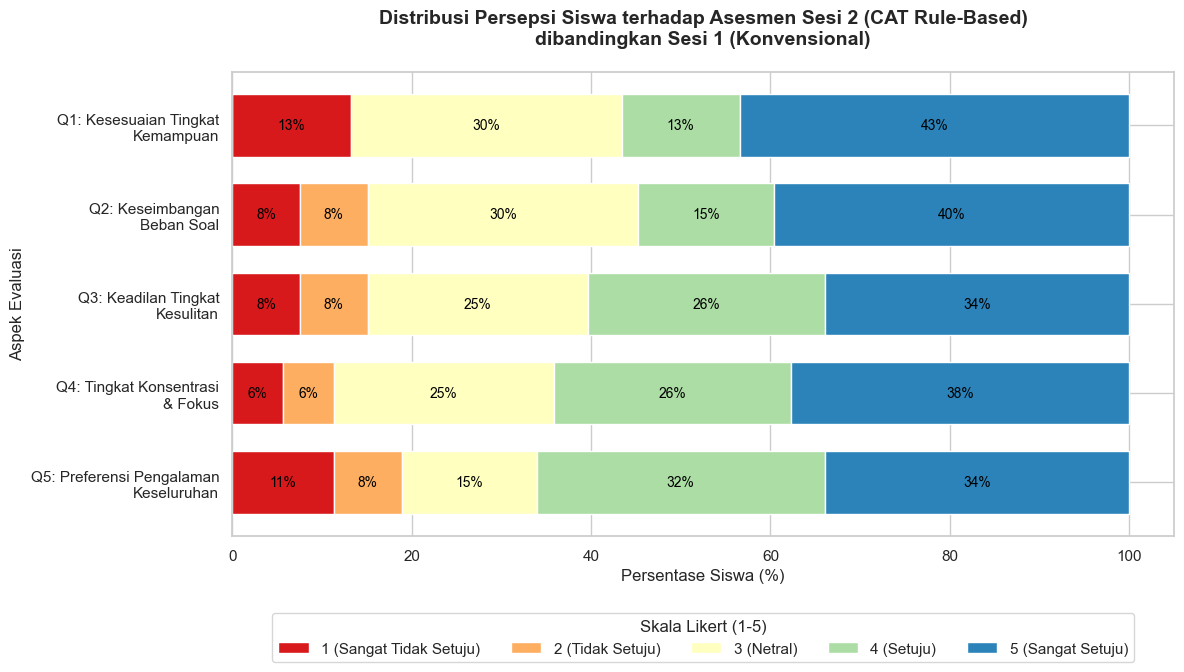

In [153]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#d7191c', '#fdae61', '#ffffbf', '#abdda4', '#2b83ba']

df_likert.plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='white', width=0.7)

plt.title('Distribusi Persepsi Siswa terhadap Asesmen Sesi 2 (CAT Rule-Based)\ndibandingkan Sesi 1 (Konvensional)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Persentase Siswa (%)', fontsize=12)
plt.ylabel('Aspek Evaluasi', fontsize=12)

plt.legend(title='Skala Likert (1-5)', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=5)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(x, y, f'{width:.0f}%', ha='center', va='center', fontsize=10, color='black')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [155]:
print("\n" + "="*90)
print("DATA DETAIL KUESIONER 53 SISWA (Q1-Q5 & SARAN)")
print("="*90)

col_saran = [col for col in df_final.columns if 'Menurut kamu' in str(col)][0]
kolom_kelas = [col for col in df_final.columns if 'Kelas' in str(col) or 'kelas' in str(col).lower()][0]

df_final_sorted = df_final.sort_values(by=[kolom_kelas, 'nama_sesi1'])

for i, (index, row) in enumerate(df_final_sorted.iterrows(), 1):
    nama = str(row['nama_sesi1']).title()
    kelas = str(row[kolom_kelas]).upper()
    
    q1 = row[q_cols[0]]
    q2 = row[q_cols[1]]
    q3 = row[q_cols[2]]
    q4 = row[q_cols[3]]
    q5 = row[q_cols[4]]
    
    # Saran
    saran = str(row[col_saran]).strip()
    if pd.isna(row[col_saran]) or saran.lower() == 'nan' or saran == '':
        saran = "(Tidak ada komentar)"
        
    print(f"{i:02d}. {nama}  |  {kelas}")
    print(f"    Skor  : [Q1: {q1}]  [Q2: {q2}]  [Q3: {q3}]  [Q4: {q4}]  [Q5: {q5}]")
    print(f"    Saran : \"{saran}\"")
    print("-" * 90)


DATA DETAIL KUESIONER 53 SISWA (Q1-Q5 & SARAN)
01. Ahmad Razan Alamsyah  |  X-I
    Skor  : [Q1: 3]  [Q2: 3]  [Q3: 3]  [Q4: 3]  [Q5: 3]
    Saran : "Hilangkan photo live hehe"
------------------------------------------------------------------------------------------
02. Aisyah Annuri  |  X-I
    Skor  : [Q1: 1]  [Q2: 3]  [Q3: 2]  [Q4: 2]  [Q5: 3]
    Saran : "semoga kedepannya lebih baik lagi"
------------------------------------------------------------------------------------------
03. Amalina Zahratin  |  X-I
    Skor  : [Q1: 4]  [Q2: 3]  [Q3: 3]  [Q4: 4]  [Q5: 4]
    Saran : "Tidak ada ada saran dari saya karna menurut saya sistem nya suda pas.Saya hanya kewalahan saat membaca soal yang begitu panjang saja"
------------------------------------------------------------------------------------------
04. Baiq Erji Sahaya  |  X-I
    Skor  : [Q1: 5]  [Q2: 5]  [Q3: 5]  [Q4: 5]  [Q5: 5]
    Saran : "tidak ada"
-------------------------------------------------------------------------------